In [43]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_iris, fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns


## Bagging


Mean accuracy: 0.6843077873918417
Variance: 0.0009321148742285871


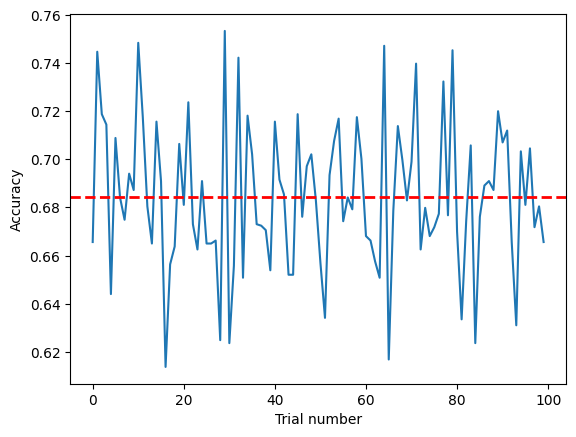

In [14]:

digits = load_digits()
X, y = digits.data, digits.target


scores = []
for _ in range(100):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9)
    clf = DecisionTreeClassifier()
    clf.fit(X_train, y_train)
    scores.append(clf.score(X_test, y_test))

print("Mean accuracy:", np.mean(scores))
print("Variance:", np.var(scores))

plt.plot(np.arange(0,100),scores)
plt.axhline(y=np.mean(scores), color='r', linestyle='--', linewidth=2)
plt.xlabel("Trial number")
plt.ylabel("Accuracy")
plt.show()


variance of accuracy over 100 trials

When repeating the train/test split 100 times, the accuracy varies significantly for a single decision tree. Decision trees are high-variance models, meaning small changes in the training data can lead to very different models. This instability causes noticeable fluctuations in accuracy. The conclusion is that a single decision tree does not generalize well and suffers from high variance.

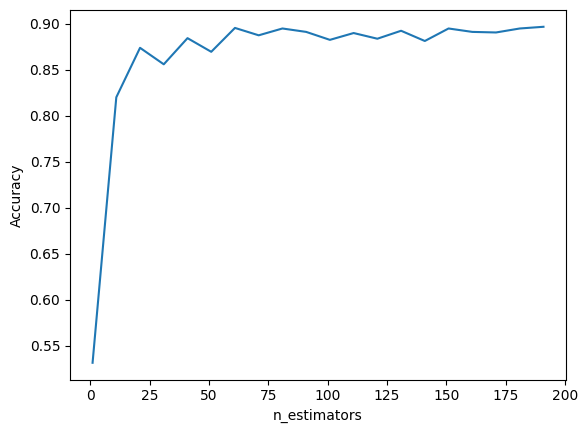

In [3]:

estimators = range(1, 201, 10)
acc = []

for n in estimators:
    bag = BaggingClassifier(
        DecisionTreeClassifier(),
        n_estimators=n,
        max_samples=0.5,
        max_features=0.5
    )
    bag.fit(X_train, y_train)
    acc.append(bag.score(X_test, y_test))

plt.plot(estimators, acc)
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()


Accuracy versus number of estimators

As the number of estimators increases, the accuracy improves rapidly at first and then stabilizes. Each additional tree helps reduce variance by averaging errors, but after a certain number of trees, the improvement becomes negligible. This shows diminishing returns when adding more estimators.

In [4]:

param_grid = {
    'max_samples': [0.3, 0.5, 0.7],
    'max_features': [0.3, 0.5, 0.7]
}

bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100)
gs = GridSearchCV(bag, param_grid, cv=3)
gs.fit(X_train, y_train)

print(gs.best_params_)


{'max_features': 0.3, 'max_samples': 0.7}


Best performance is generally obtained when max_samples and max_features are set between 0.5 and 0.7. If these values are too small, the individual models are too weak and underfit the data. If they are too large, the trees become too similar and highly correlated. A balance between diversity and strength gives the best results.

## Random Forest

In [5]:

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)
print("Accuracy:", rf.score(X_test, y_test))


Accuracy: 0.9011124845488258


Random Forest generally achieves higher accuracy than Bagging when using the same number of trees. This is because Random Forest introduces additional randomness by selecting a random subset of features at each split, which reduces correlation between trees and improves generalization.

In [6]:

rf_scores = []
for _ in range(100):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9)
    rf = RandomForestClassifier(n_estimators=200)
    rf.fit(X_train, y_train)
    rf_scores.append(rf.score(X_test, y_test))

print("RF Variance:", np.var(rf_scores))


RF Variance: 0.00022563680229067008



Random Forest shows lower variance than Bagging. Both methods reduce variance compared to a single decision tree, but Random Forest further reduces variance thanks to feature-level randomness.

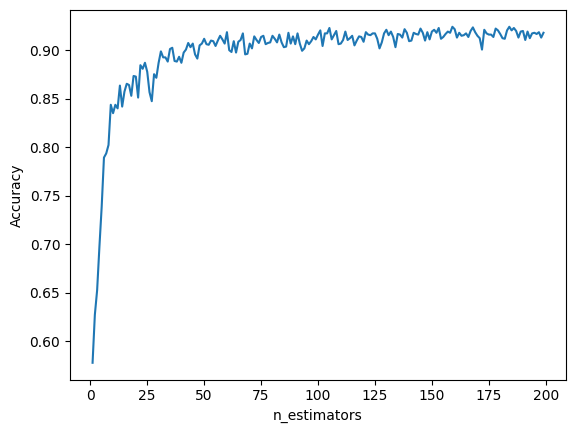

In [18]:
estimators = range(1, 200)

rf_scores = []
for n in estimators:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    rf_scores.append(rf.score(X_test, y_test))

plt.plot(estimators, rf_scores)
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

Accuracy increases as the number of trees increases, then reaches a plateau. Beyond roughly 50 trees, adding more trees does not significantly improve performance but increases computation time.

In [21]:

et = ExtraTreesClassifier(n_estimators=200)
et.fit(X_train, y_train)
print("ExtraTrees Accuracy:", et.score(X_test, y_test))


ExtraTrees Accuracy: 0.9332509270704573


ExtraTreesClassifier often achieves slightly better accuracy than RandomForestClassifier. Because split thresholds are chosen randomly, the trees are more diverse, which can reduce variance. Extra Trees also tends to train faster.

## Boosting (AdaBoost)

/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.wa

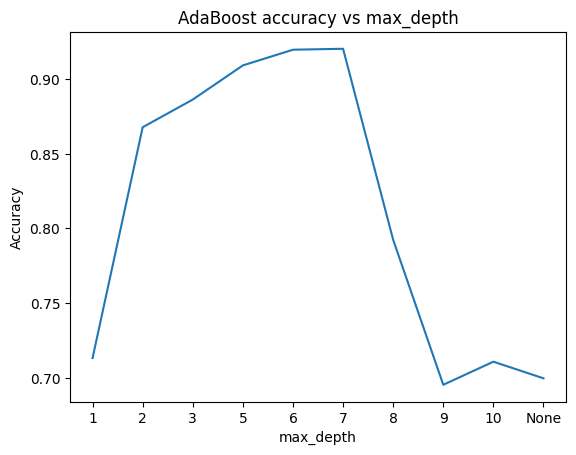

In [34]:
depths = [1, 2, 3, 5,6,7,8,9, 10, None]
accuracies = []

for d in depths:
    clf = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=d),
        n_estimators=200,
        learning_rate=2
    )
    clf.fit(X_train, y_train)
    accuracies.append(clf.score(X_test, y_test))

plt.figure()
plt.plot([str(d) for d in depths], accuracies)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("AdaBoost accuracy vs max_depth")
plt.show()


Using a small max_depth (<7 in our case)produces weak learners, which is ideal for boosting and leads to better generalization. Using a large max_depth (>7 in our case)creates strong learners that overfit the data.

/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.wa

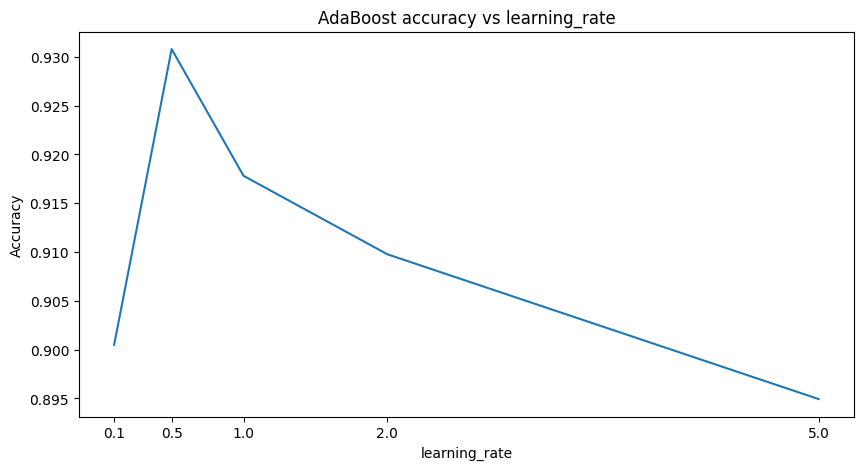

In [39]:
learning_rates = [ 0.1, 0.5, 1.0, 2.0,5.0]
accuracies = []

for lr in learning_rates:
    clf = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=5),
        n_estimators=200,
        learning_rate=lr
    )
    clf.fit(X_train, y_train)
    accuracies.append(clf.score(X_test, y_test))

plt.figure(figsize=(10,5))
plt.plot(learning_rates, accuracies)
plt.xlabel("learning_rate")
plt.xticks(learning_rates)
plt.ylabel("Accuracy")
plt.title("AdaBoost accuracy vs learning_rate")
plt.show()


A smaller learning rate leads to slower but more stable learning, while a larger learning rate will cause overfitting.

/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/snds/.local/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.wa

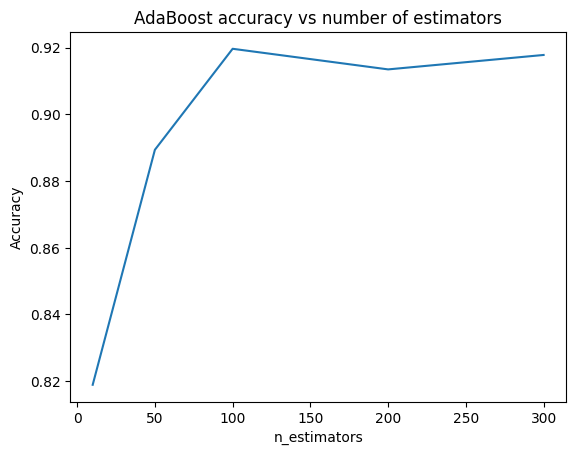

In [41]:
n_estimators_list = [10, 50, 100, 200, 300]
accuracies = []

for n in n_estimators_list:
    clf = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=5),
        n_estimators=n,
        learning_rate=1.0
    )
    clf.fit(X_train, y_train)
    accuracies.append(clf.score(X_test, y_test))

plt.figure()
plt.plot(n_estimators_list, accuracies)
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost accuracy vs number of estimators")
plt.show()


Increasing the number of estimators improves performance up to a point (100 estimators in our case), after which it will cause overfitting and longer training times for very little gain in accuracy if any.

## IRIS

In [51]:

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print("IRIS Accuracy:", rf.score(X_test, y_test))


IRIS Accuracy: 0.8947368421052632


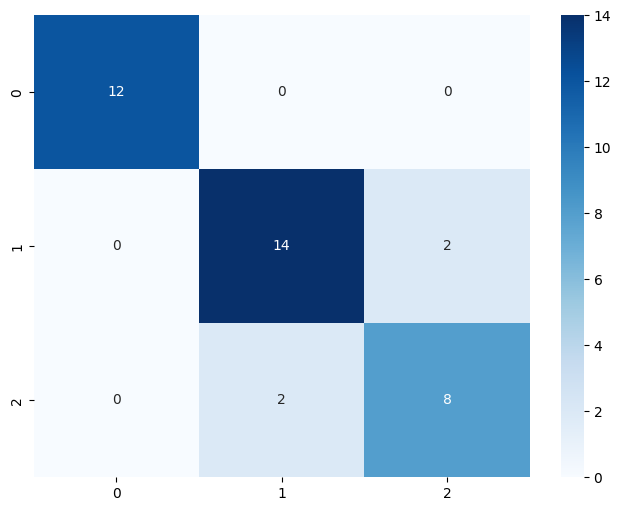

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize =(8,6))
sns.heatmap(cm,annot = True, fmt='d', cmap ='Blues')
plt.show()

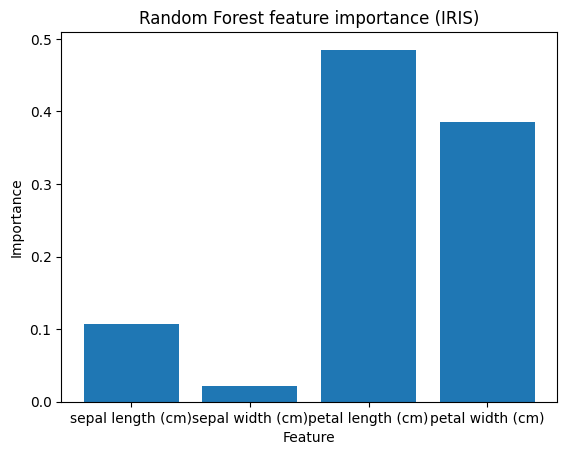

In [53]:
importances = rf.feature_importances_

plt.figure()
plt.bar(iris.feature_names, importances)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest feature importance (IRIS)")
plt.show()


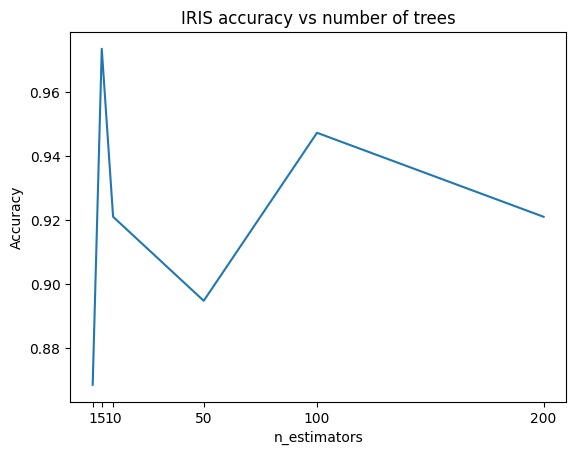

In [56]:
estimators = [1, 5, 10, 50, 100, 200]
acc = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n)
    model.fit(X_train, y_train)
    acc.append(model.score(X_test, y_test))

plt.figure()
plt.plot(estimators, acc)
plt.xlabel("n_estimators")
plt.xticks(estimators)
plt.ylabel("Accuracy")
plt.title("IRIS accuracy vs number of trees")
plt.show()


5 estimators is the optimal choice which makes sense given the dataset, anything over that would be overkill and a waste of resources and time for less accuracy.

## MNIST

In [57]:

mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9)

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf.fit(X_train, y_train)
print("MNIST Accuracy:", rf.score(X_test, y_test))


MNIST Accuracy: 0.9442380952380952


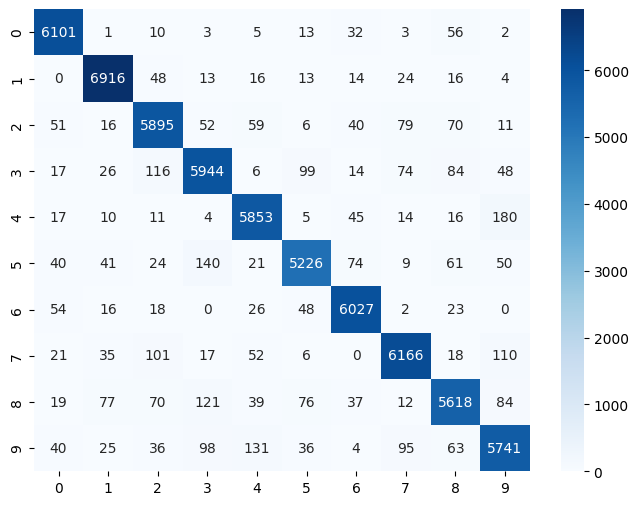

In [58]:
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize =(8,6))
sns.heatmap(cm,annot = True, fmt='d', cmap ='Blues')
plt.show()

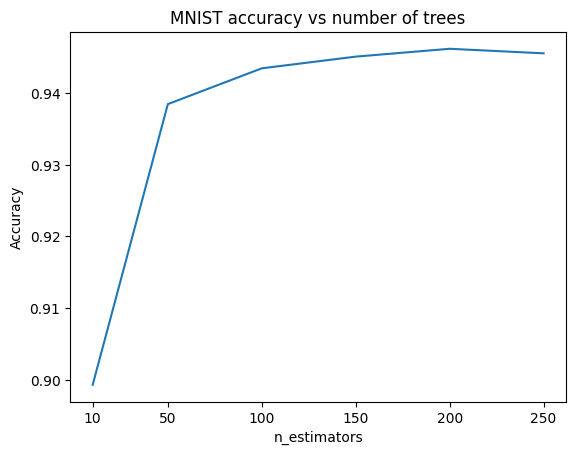

In [60]:
estimators = [10, 50, 100,150,200,250]
acc = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, n_jobs=-1)
    model.fit(X_train, y_train)
    acc.append(model.score(X_test, y_test))

plt.figure()
plt.plot(estimators, acc)
plt.xlabel("n_estimators")
plt.xticks(estimators)
plt.ylabel("Accuracy")
plt.title("MNIST accuracy vs number of trees")
plt.show()


100 estimators is the optimal choice, accuracy plateaus after that and any marginal gain in accuracy is not worth the computation time.

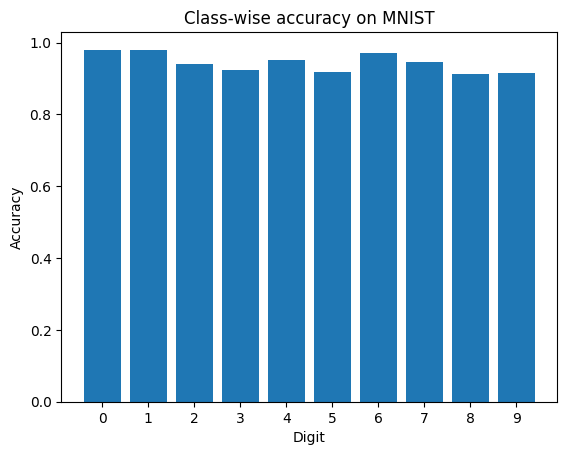

In [62]:
class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar(range(10), class_acc)
plt.xlabel("Digit")
plt.xticks(range(0,10))
plt.ylabel("Accuracy")
plt.title("Class-wise accuracy on MNIST")
plt.show()
